# Getting started with DATA

In [59]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [60]:
df = pd.read_csv('/kaggle/input/titanic/train.csv')

In [61]:
# 1. how big is the data?
df.shape

(891, 12)

In [62]:
# 2. how does the data look like?
# df.head()
df.sample(5) #for random rows to get a better view of the data

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
640,641,0,3,"Jensen, Mr. Hans Peder",male,20.0,0,0,350050,7.8542,NaN,S
766,767,0,1,"Brewe, Dr. Arthur Jackson",male,NaN,0,0,112379,39.6000,NaN,C
434,435,0,1,"Silvey, Mr. William Baird",male,50.0,1,0,13507,55.9000,E44,S
698,699,0,1,"Thayer, Mr. John Borland",male,49.0,1,1,17421,110.8833,C68,C
751,752,1,3,"Moor, Master. Meier",male,6.0,0,1,392096,12.4750,E121,S


In [63]:
# 3. what is the datatype of the columns?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [64]:
# 4. Are there any missing values?
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [35]:
# 5. how does the data look like mathematically?
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [65]:
# 6. Are there any duplicate values?
df.duplicated().sum() 
# if present then drop those rows with duplicated values using drop duplicate in pandas

0

In [37]:
# 7. are the data columns correlated?
numeric_columns = [col for col in df.columns if df[col].dtype != 'object']
df_numeric = df[numeric_columns]
df_numeric

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500
...,...,...,...,...,...,...,...
886,887,0,2,27.0,0,0,13.0000
887,888,1,1,19.0,0,0,30.0000
888,889,0,3,NaN,1,2,23.4500
889,890,1,1,26.0,0,0,30.0000


This is karl pearson's correlation coefficient:
* Ranging from -1 to 1
* 1 means perfect positive correlation
* 0 means no correlation
* -1 means perfect negative correlation

In [38]:
df_numeric.corr() # for whole numerical columns

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


<Axes: >

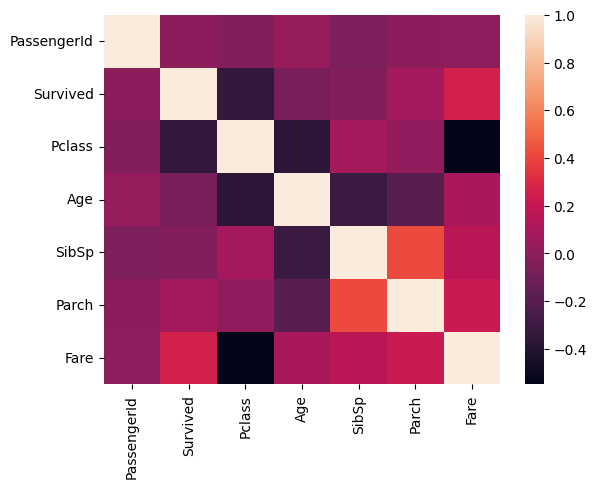

In [67]:
sns.heatmap(df_numeric.corr())

In [39]:
df_numeric.corr()['Survived'] #for particular column

PassengerId   -0.005007
Survived       1.000000
Pclass        -0.338481
Age           -0.077221
SibSp         -0.035322
Parch          0.081629
Fare           0.257307
Name: Survived, dtype: float64

# Univariate Analysis
- It means analyzing a single variable.
- Common techniques include:
  - Descriptive statistics (mean, median, mode)
  - Visualization (histograms, box plots)


There are two types of variables:
1. Categorical Variables - represent categories or groups (e.g., gender, color,(can be numbers but not continuous))
2. Numerical Variables - represent measurable quantities (e.g., age, income, temperature)

## 1. Categorical Data

### Countplot

<Axes: xlabel='Survived', ylabel='count'>

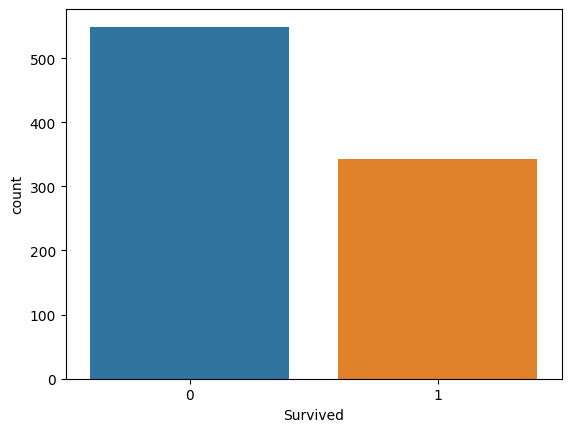

In [40]:
sns.countplot(x='Survived', data=df)

<Axes: xlabel='Pclass', ylabel='count'>

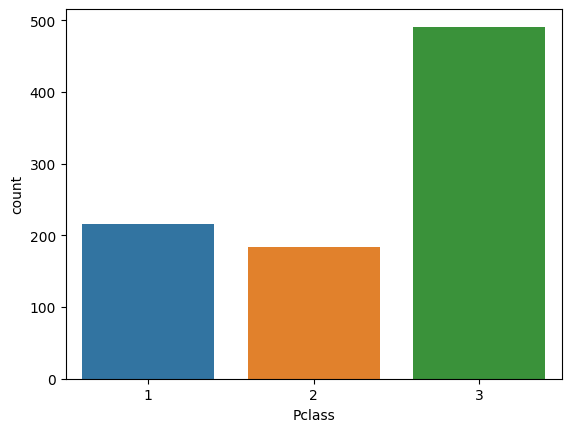

In [68]:
sns.countplot(x='Pclass',data=df)

<Axes: xlabel='SibSp', ylabel='count'>

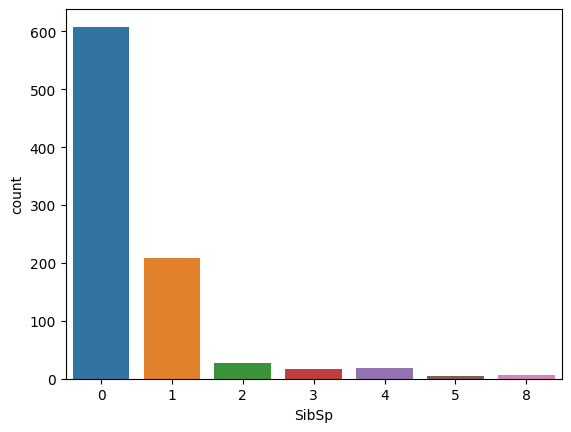

In [70]:
sns.countplot(x='SibSp',data=df)

### 2. Pie chart

<Axes: ylabel='count'>

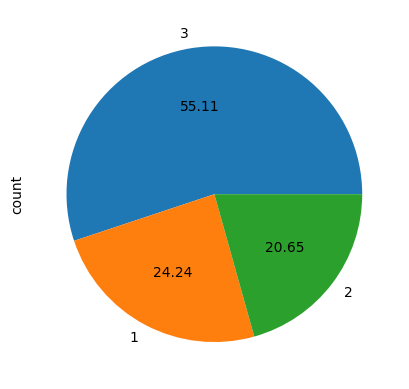

In [43]:
df['Pclass'].value_counts().plot(kind='pie',autopct='%.2f') # change 'kind' for different plots, autopct for displaying percentage

## 2. Numerical Data

### a. histogram

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Fare', ylabel='Count'>

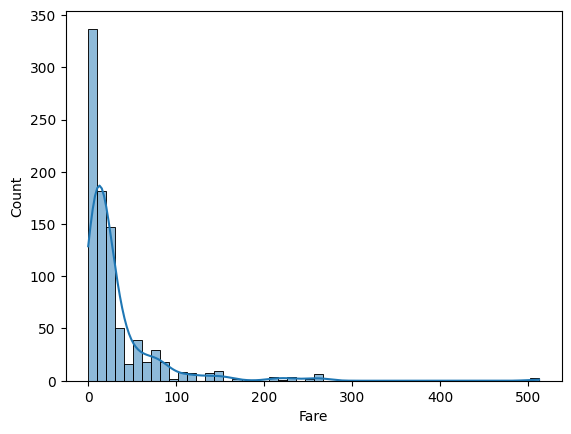

In [72]:
sns.histplot(df['Fare'],bins=50,kde=True)


### b. distplot

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


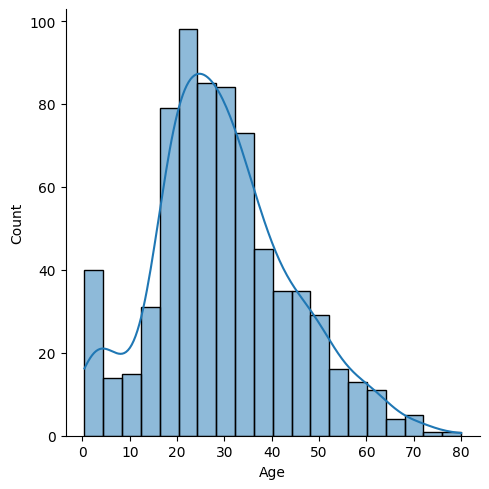

In [73]:
sns.displot(df['Age'],kde=True)  # sns.distplot is deprecated so sns.displot with kde=True

### c. boxplot



<Axes: ylabel='Age'>

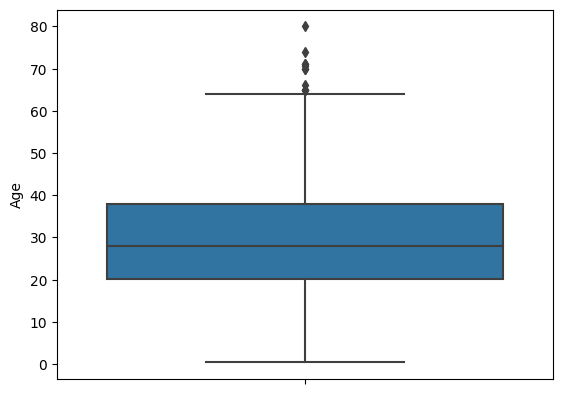

In [74]:
sns.boxplot(y='Age',data=df) #change x,y axis for horizontal and vertical plot respectively.

<Axes: xlabel='Pclass', ylabel='Age'>

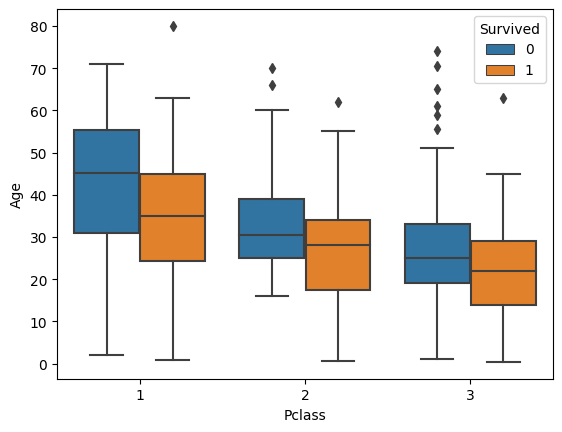

In [86]:
# for plotting numerical column with categorical column
sns.boxplot(x='Pclass',y='Age',hue=df['Survived'],data=df) #x as categorical, y as numerical

<Axes: xlabel='Survived', ylabel='Fare'>

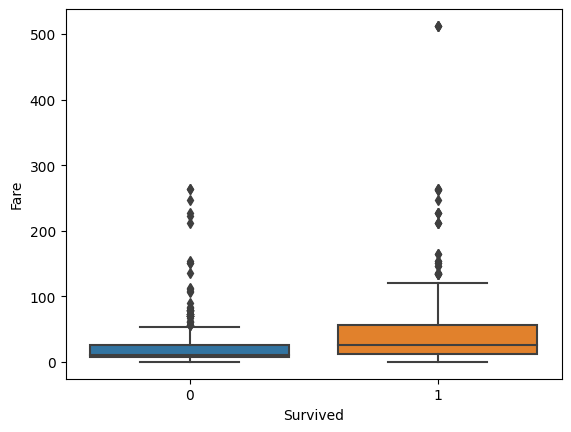

In [48]:
sns.boxplot(x='Survived',y='Fare',data=df) 

In [49]:
# Skewness check. 
# 1 means positively skewed(right), 0 means symmetrical, -1 means negatively skewed(left)
df['Age'].skew() 

0.38910778230082693

## Bivariate and Multivariate Analysis
- Bivariate: Analysis done between two variables
- Multivariate: Analysis done between more than two variables

In [50]:
tips = sns.load_dataset('tips')

### 1. Scatter Plot (Num - Num)

<Axes: xlabel='total_bill', ylabel='tip'>

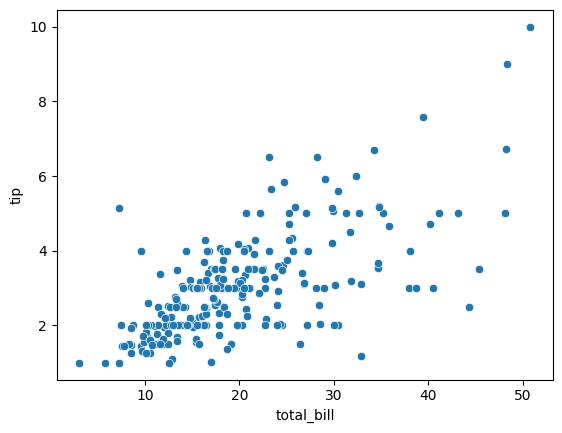

In [51]:
sns.scatterplot(x=tips['total_bill'], y=tips['tip'])

<Axes: xlabel='total_bill', ylabel='tip'>

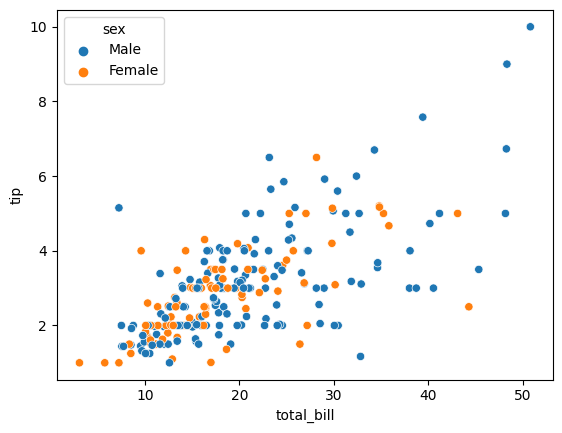

In [75]:
# Lets say we also want to check males and females in this plot, we add 'hue' attribute to the 'sex' column
sns.scatterplot(x=tips['total_bill'],y=tips['tip'],hue=tips['sex'])

<Axes: xlabel='total_bill', ylabel='tip'>

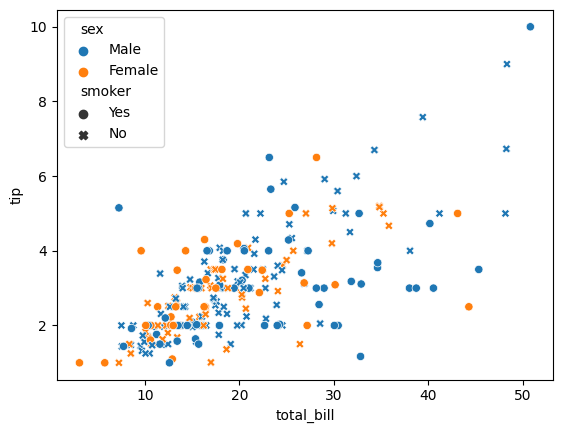

In [53]:
# Lets say we also want to analyse another variable in this same plot, we add 'style' attribute to the 'smoker' column
# similary one more can be added to 'size' attribute
sns.scatterplot(x=tips['total_bill'],y=tips['tip'],hue=tips['sex'], style=tips['smoker'])

### 2. Bar Plot (Num - Cat)

<Axes: xlabel='Pclass', ylabel='Age'>

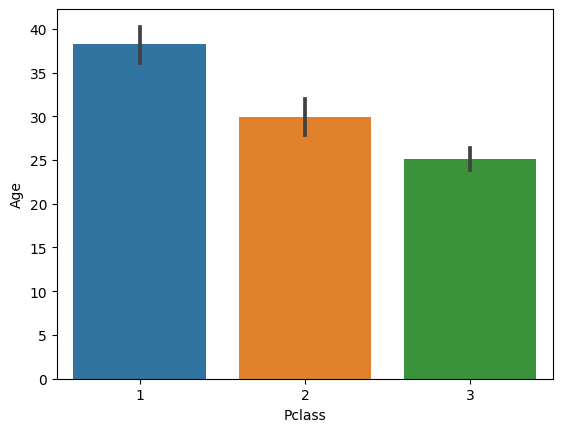

In [56]:
sns.barplot(x=df['Pclass'],y=df['Age'])

<Axes: xlabel='Pclass', ylabel='Fare'>

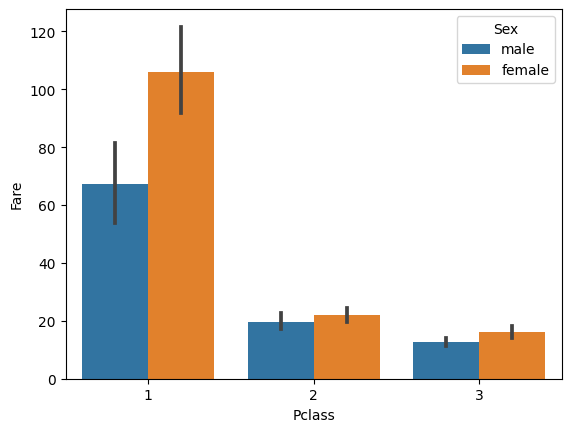

In [78]:
# Can add more variable using 'hue' attribute
sns.barplot(x=df['Pclass'],y=df['Fare'],hue=df['Sex'])

### 3. Box Plot ( num -cat)

<Axes: xlabel='Sex', ylabel='Age'>

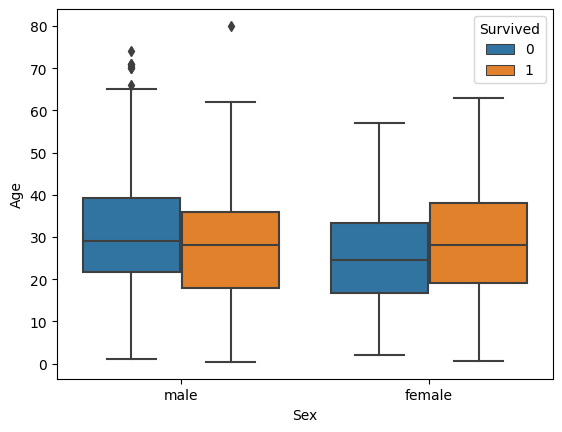

In [80]:
sns.boxplot(x=df['Sex'],y=df['Age'],hue=df['Survived'])

### 4. Dist Plot (num - cat)

/tmp/ipykernel_47/2663530416.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['Survived']==0]['Age'], hist=False) # blue curve defines the curve of the age of the people who died
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/tmp/ipykernel_47/2663530416.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-leve

<Axes: xlabel='Age', ylabel='Density'>

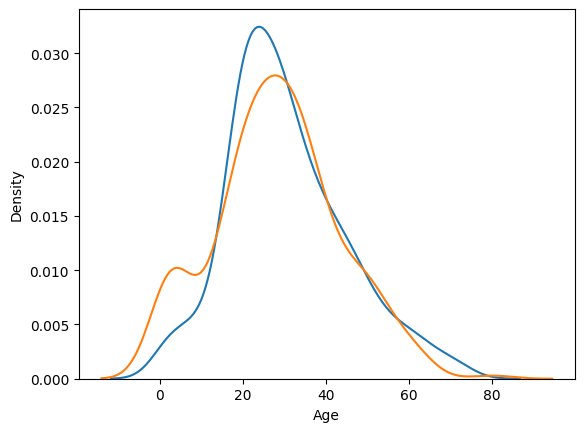

In [83]:
sns.distplot(df[df['Survived']==0]['Age'], hist=False) # blue curve defines the curve of the age of the people who died
sns.distplot(df[df['Survived']==1]['Age'], hist=False) # orange curve defines the curve of the age of the people who survived

- For younger age group (0-18), the probability of surviving is greater than not surviving.
- For middle age group (19-60), the probability of surviving is slightly greater than not surviving.
- For older age group (60+), the probability of not surviving is greater than surviving.

### 5. Heatmap (Cat - Cat)

<Axes: xlabel='Survived', ylabel='Pclass'>

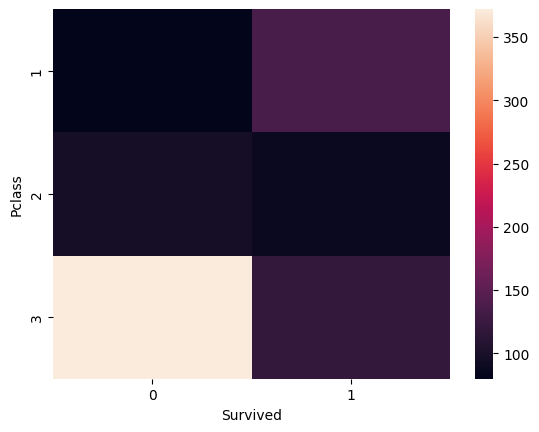

In [85]:
# for bigger grid we can use heatmap
sns.heatmap(pd.crosstab(df['Pclass'],df['Survived']))